In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

Destiny's To Do:

- [x] Reclassify core/peripheral stations using data-driven approach
- [x] Investigate Downtown Berkeley Census Data
- [x] Visualizations
- [x] Missing data (report)
- [] Clean up code (put notebook code into python file)


## New Transit Data

In [3]:
transit = pd.read_csv('../data/transit_gdf.csv')
transit

,Unnamed: 0,station_id,name,latitude,longitude,address,city,county,zipcode,agency,mode,geometry
0,0,12TH,12th St. Oakland City Center,37.803768,-122.271450,1245 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.27145 37.803768)
1,1,16TH,16th St. Mission,37.765062,-122.419694,2000 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.419694 37.765062)
2,2,19TH,19th St. Oakland,37.808350,-122.268602,1900 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.268602 37.80835)
3,3,24TH,24th St. Mission,37.752470,-122.418143,2800 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.418143 37.75247)
4,4,ANTC,Antioch,37.995388,-121.780420,1600 Slatten Ranch Road,Antioch,Contra Costa,94509.0,BART,Heavy Rail,POINT (-121.78042 37.995388)
...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,santa_clara,Santa Clara Caltrain Station,37.353384,-121.936465,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-121.936465 37.353384)
77,77,south_sf,South San Francisco Caltrain Station,37.655941,-122.404979,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.404979006 37.655941416)
78,78,stanford,Stanford,37.438950,-122.157150,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.15715 37.43895)
79,79,sunnyvale,Sunnyvale,37.378934,-122.031500,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.0315 37.378934)


In [4]:
transit['name'].values

<StringArray>
[        '12th St. Oakland City Center',
                     '16th St. Mission',
                     '19th St. Oakland',
                     '24th St. Mission',
                              'Antioch',
                                'Ashby',
                          'Balboa Park',
                             'Bay Fair',
             'Berryessa/North San Jose',
                        'Castro Valley',
                'Civic Center/UN Plaza',
                             'Coliseum',
                                'Colma',
                              'Concord',
                            'Daly City',
                    'Downtown Berkeley',
                    'Dublin/Pleasanton',
                 'El Cerrito del Norte',
                     'El Cerrito Plaza',
                          'Embarcadero',
                              'Fremont',
                            'Fruitvale',
                            'Glen Park',
                              'Hayward',
  

In [5]:
duplicated_station = transit['name'].duplicated()
transit.loc[duplicated_station, 'name'] = 'Millbrae Caltrain Station'

In [6]:
classification = pd.read_csv('../output/classification_results_fy2025.csv')
classification = classification.rename(columns = {'consensus' : "station_type"})
classification

,station,agency,metric,avg_weekday_exits,rank,method_percentile,method_kmeans,method_jenks,core_votes,station_type
0,Embarcadero,BART,avg_weekday_exits,17741,1,core,core,core,3,core
1,Montgomery Street,BART,avg_weekday_exits,14342,2,core,core,core,3,core
2,Powell Street,BART,avg_weekday_exits,11002,3,core,core,core,3,core
3,Civic Center,BART,avg_weekday_exits,9172,4,core,core,core,3,core
4,San Francisco,Caltrain,avg_mid_week_ridership_AMWR,6874,5,core,core,core,3,core
...,...,...,...,...,...,...,...,...,...,...
75,Broadway,Caltrain,avg_mid_week_ridership_AMWR,91,76,peripheral,peripheral,peripheral,0,peripheral
76,Blossom Hill,Caltrain,avg_mid_week_ridership_AMWR,71,77,peripheral,peripheral,peripheral,0,peripheral
77,Capitol,Caltrain,avg_mid_week_ridership_AMWR,49,78,peripheral,peripheral,peripheral,0,peripheral
78,College Park,Caltrain,avg_mid_week_ridership_AMWR,41,79,peripheral,peripheral,peripheral,0,peripheral


In [7]:
classification['station_id'] = classification['station'] + '_' + classification['agency']
classification['station_id'].sort_values().values

<StringArray>
[  '12th Street / Oakland City Center_BART',
                 '16th Street Mission_BART',
                 '19th Street Oakland_BART',
                     '22nd Street_Caltrain',
                 '24th Street Mission_BART',
                             'Antioch_BART',
                               'Ashby_BART',
                         'Balboa Park_BART',
                             'Bayfair_BART',
                        'Bayshore_Caltrain',
                         'Belmont_Caltrain',
                            'Berkeley_BART',
          'Berryessa / North San Jos_BART',
                    'Blossom Hill_Caltrain',
                        'Broadway_Caltrain',
                      'Burlingame_Caltrain',
                  'California Ave_Caltrain',
                         'Capitol_Caltrain',
                       'Castro Valley_BART',
                        'Civic Center_BART',
                            'Coliseum_BART',
                    'College Park_Caltrai

In [8]:
list(set(transit['name'].values) ^ set(classification['station'].values)) 


['16th Street Mission',
 'Blossom Hill Caltrain Station',
 '19th Street Oakland',
 'San Bruno Caltrain Station',
 '24th Street Mission',
 'Montgomery St.',
 'Powell St.',
 'South San Francisco Caltrain Station',
 '16th St. Mission',
 'Millbrae Caltrain Station',
 'Bayfair',
 '19th St. Oakland',
 'Capitol Caltrain Station',
 'Montgomery Street',
 'Blossom Hill',
 'Tamien Caltrain Station',
 '12th St. Oakland City Center',
 'North Concord',
 'Berryessa/North San Jose',
 'Civic Center',
 'Berryessa / North San Jos\x8e',
 'Pleasant Hill',
 'Santa Clara',
 'California Avenue',
 'Pleasant Hill/Contra Costa Centre',
 'North Concord/Martinez',
 'Capitol',
 'Bay Fair',
 'El Cerrito Del Norte',
 'San Francisco',
 'Warm Springs/South Fremont',
 '24th St. Mission',
 'El Cerrito del Norte',
 'Tamien',
 'California Ave',
 'San Francisco Caltrain Station',
 'Powell Street',
 'Berkeley',
 '12th Street / Oakland City Center',
 'Warm Springs',
 'Downtown Berkeley',
 'Santa Clara Caltrain Station',
 'Sta

In [9]:
classification['station_id'] = classification['station_id'].replace({
               '12th Street / Oakland City Center_BART' : "12th St. Oakland City Center",
                 '16th Street Mission_BART' : "16th St. Mission",
                 '19th Street Oakland_BART' : "19th St. Oakland",
                     '22nd Street_Caltrain' : "22nd Street",
                 '24th Street Mission_BART' : "24th St. Mission",
                             'Antioch_BART' : "Antioch",
                               'Ashby_BART' : "Ashby",
                         'Balboa Park_BART' : "Balboa Park",
                             'Bayfair_BART' : "Bay Fair",
                        'Bayshore_Caltrain' : "Bayshore",
                         'Belmont_Caltrain' : "Belmont",
                            'Berkeley_BART' : "Downtown Berkeley",
          'Berryessa / North San Jos_BART' : "Berryessa/North San Jose",
                    'Blossom Hill_Caltrain' : "Blossom Hill Caltrain Station",
                        'Broadway_Caltrain' : "Broadway",
                      'Burlingame_Caltrain' : "Burlingame",
                  'California Ave_Caltrain' : "California Avenue",
                         'Capitol_Caltrain' : "Capitol Caltrain Station",
                       'Castro Valley_BART' : "Castro Valley",
                        'Civic Center_BART' : "Civic Center/UN Plaza",
                            'Coliseum_BART' : "Coliseum",
                    'College Park_Caltrain' : "College Park",
                               'Colma_BART' : "Colma",
                             'Concord_BART' : "Concord",
                           'Daly City_BART' : "Daly City",
                   'Dublin/Pleasanton_BART' : "Dublin/Pleasanton",
                'El Cerrito Del Norte_BART' : "El Cerrito del Norte",
                    'El Cerrito Plaza_BART' : "El Cerrito Plaza",
                         'Embarcadero_BART' : "Embarcadero",
                             'Fremont_BART' : "Fremont",
                           'Fruitvale_BART' : "Fruitvale",
                          'Gilroy_Caltrain' : "Gilroy",
                           'Glen Park_BART' : "Glen Park",
                    'Hayward Park_Caltrain' : "Hayward Park",
                             'Hayward_BART' : "Hayward",
                       'Hillsdale_Caltrain' : "Hillsdale",
                           'Lafayette_BART' : "Lafayette",
                        'Lake Merritt_BART' : "Lake Merritt",
                        'Lawrence_Caltrain' : "Lawrence",
                           'MacArthur_BART' : "MacArthur",
                      'Menlo Park_Caltrain' : "Menlo Park",
                            'Millbrae_BART' : "Millbrae",
                        'Millbrae_Caltrain' : "Millbrae Caltrain Station",
                            'Milpitas_BART' : "Milpitas",
                   'Montgomery Street_BART' : "Montgomery St.",
                     'Morgan Hill_Caltrain' : "Morgan Hill",
                   'Mountain View_Caltrain' : "Mountain View",
                      'North Berkeley_BART' : "North Berkeley",
                       'North Concord_BART' : "North Concord/Martinez",
       'Oakland International Airport_BART' : "Oakland International Airport",
                              'Orinda_BART' : "Orinda",
                       'Palo Alto_Caltrain' : "Palo Alto",
                    'Pittsburg Center_BART' : "Pittsburg Center",
                 'Pittsburg/Bay Point_BART' : "Pittsburg/Bay Point",
                       'Pleasant Hill_BART' : "Pleasant Hill/Contra Costa Centre",
                       'Powell Street_BART' : "Powell St.",
                    'Redwood City_Caltrain' : "Redwood City",
                            'Richmond_BART' : "Richmond",
                           'Rockridge_BART' : "Rockridge",
                     'San Antonio_Caltrain' : "San Antonio",
                           'San Bruno_BART' : "San Bruno",
                       'San Bruno_Caltrain' : "San Bruno Caltrain Station",
                      'San Carlos_Caltrain' : "San Carlos",
 'San Francisco International Airport_BART' : "San Francisco International Airport",
                   'San Francisco_Caltrain' : "San Francisco Caltrain Station",
                'San Jose Diridon_Caltrain' : "San Jose Diridon",
                         'San Leandro_BART' : "San Leandro",
                      'San Martin_Caltrain' : "San Martin",
                       'San Mateo_Caltrain' : "San Mateo",
                     'Santa Clara_Caltrain' : "Santa Clara Caltrain Station",
                       'South Hayward_BART' : "South Hayward",
                 'South San Francisco_BART' : "South San Francisco",
             'South San Francisco_Caltrain' : "South San Francisco Caltrain Station",
                       'Sunnyvale_Caltrain' : "Sunnyvale",
                          'Tamien_Caltrain' : "Tamien Caltrain Station",
                          'Union City_BART' : "Union City",
                        'Walnut Creek_BART' : "Walnut Creek",
                        'Warm Springs_BART' : "Warm Springs/South Fremont",
              'West Dublin/Pleasanton_BART' : "West Dublin/Pleasanton",
                        'West Oakland_BART' : "West Oakland"
})

In [10]:
list(set(transit['name'].values) ^ set(classification['station_id'].values)) 

['Stanford']

In [11]:
df = pd.merge(transit, classification[['station_id', 'station_type']], how = "inner", left_on = 'name', 
         right_on='station_id')
df

,Unnamed: 0,station_id_x,name,latitude,longitude,address,city,county,zipcode,agency,mode,geometry,station_id_y,station_type
0,0,12TH,12th St. Oakland City Center,37.803768,-122.271450,1245 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.27145 37.803768),12th St. Oakland City Center,core
1,1,16TH,16th St. Mission,37.765062,-122.419694,2000 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.419694 37.765062),16th St. Mission,core
2,2,19TH,19th St. Oakland,37.808350,-122.268602,1900 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.268602 37.80835),19th St. Oakland,core
3,3,24TH,24th St. Mission,37.752470,-122.418143,2800 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.418143 37.75247),24th St. Mission,core
4,4,ANTC,Antioch,37.995388,-121.780420,1600 Slatten Ranch Road,Antioch,Contra Costa,94509.0,BART,Heavy Rail,POINT (-121.78042 37.995388),Antioch,peripheral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,75,san_mateo,San Mateo,37.568240,-122.323900,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.3239 37.56824),San Mateo,peripheral
76,76,santa_clara,Santa Clara Caltrain Station,37.353384,-121.936465,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-121.936465 37.353384),Santa Clara Caltrain Station,peripheral
77,77,south_sf,South San Francisco Caltrain Station,37.655941,-122.404979,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.404979006 37.655941416),South San Francisco Caltrain Station,peripheral
78,79,sunnyvale,Sunnyvale,37.378934,-122.031500,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.0315 37.378934),Sunnyvale,peripheral


In [12]:
df.to_csv("../data/new_stations_transit_data.csv")

What is the difference between census_tract_data_2024.csv and census_tract_data_2024_clean.csv
- No difference ...clean made in py file, while other made in notebook. (delete notebook)

In [13]:
pd.set_option('display.max_columns', None)

In [14]:
census_data = pd.read_csv('../data/census_tract_data_2024.csv')
census_data.iloc[143:149, :]

,NAME,total_pop,median_age,total_pop_race,white_alone,black_alone,aian_alone,asian_alone,nhpi_alone,other_race_alone,two_or_more_races,median_household_income,per_capita_income,total_pop_poverty_calc,pop_below_poverty,total_housing_units,total_occupied_units,owner_occupied,renter_occupied,total_households,owner_occ_no_vehicle,renter_occ_no_vehicle,median_gross_rent,median_home_value,total_workers_16plus,drove_alone,public_transit_commuters,bicycle_commuters,walked_commuters,worked_from_home,aggregate_travel_time_mins,labor_force,employed,unemployed,pop_25plus,bachelors_degree,masters_degree,professional_degree,doctorate_degree,foreign_born,total_pop_nativity,state,county,tract,GEOID,county_name,households_no_vehicle,pct_no_vehicle,pop_nonwhite,pct_nonwhite,pct_white,pct_black,pct_asian,poverty_rate,pct_renter,pct_owner,pct_transit_commute,pct_drove_alone,pct_bike_commute,pct_walk_commute,pct_wfh,mean_travel_time_mins,unemployment_rate,pop_bachelors_plus,pct_bachelors_plus,pct_foreign_born
143,Census Tract 4233; Alameda County; California,3623,41.6,3623,1764,712,4,300,0,308,535,101571.0,62484.0,3623,617,1730,1476,829,647,1476,61,192,2137.0,1101900.0,1923,638,184,215,90,687,NaN,2048,1954,94,2758,752,456,194,99,599,3623,6,1,423300,6001423300,Alameda,253,17.14,1859,51.31,48.69,19.65,8.28,17.03,43.83,56.17,9.57,33.18,11.18,4.68,35.73,NaN,4.59,1501,54.42,16.53
144,Census Tract 4234; Alameda County; California,5218,35.0,5218,2392,1019,0,551,0,705,551,145789.0,74470.0,5218,927,2352,1974,965,1009,1974,60,271,2311.0,1362400.0,2906,1151,456,292,101,895,58440.0,3093,2923,170,3980,1068,1000,270,236,921,5218,6,1,423400,6001423400,Alameda,331,16.77,2826,54.16,45.84,19.53,10.56,17.77,51.11,48.89,15.69,39.61,10.05,3.48,30.80,20.11,5.50,2574,64.67,17.65
145,Census Tract 4235; Alameda County; California,3768,33.3,3768,2198,336,0,389,10,217,618,103702.0,66770.0,3637,403,1694,1587,488,1099,1587,52,294,2075.0,1162700.0,2097,619,250,197,159,574,42810.0,2178,2106,72,2755,960,638,154,207,578,3768,6,1,423500,6001423500,Alameda,346,21.80,1570,41.67,58.33,8.92,10.32,11.08,69.25,30.75,11.92,29.52,9.39,7.58,27.37,20.41,3.31,1959,71.11,15.34
146,Census Tract 4236.01; Alameda County; California,2603,40.7,2603,1630,70,26,403,2,237,235,166310.0,90543.0,2568,326,1247,1136,555,581,1136,11,70,2222.0,1421900.0,1394,397,178,72,177,545,NaN,1541,1424,117,2046,611,532,99,316,506,2603,6,1,423601,6001423601,Alameda,81,7.13,973,37.38,62.62,2.69,15.48,12.69,51.14,48.86,12.77,28.48,5.16,12.70,39.10,NaN,7.59,1558,76.15,19.44
147,Census Tract 4236.02; Alameda County; California,5621,24.1,5621,2892,204,0,1607,0,296,622,53952.0,39294.0,5497,2295,2709,2255,664,1591,2255,77,831,2021.0,909500.0,2584,596,394,24,639,853,NaN,2826,2584,242,2662,743,560,106,266,1261,5621,6,1,423602,6001423602,Alameda,908,40.27,2729,48.55,51.45,3.63,28.59,41.75,70.55,29.45,15.25,23.07,0.93,24.73,33.01,NaN,8.56,1675,62.92,22.43
148,Census Tract 4237; Alameda County; California,3381,26.3,3381,2068,137,0,661,2,133,380,95833.0,72496.0,2846,653,1420,1152,500,652,1152,38,296,2132.0,2000001.0,1595,495,245,21,270,503,34190.0,1765,1665,100,1755,483,350,182,400,557,3381,6,1,423700,6001423700,Alameda,334,28.99,1313,38.83,61.17,4.05,19.55,22.94,56.60,43.40,15.36,31.03,1.32,16.93,31.54,21.44,5.67,1415,80.63,16.47


In [15]:
census_data["GEOID"] = census_data["GEOID"].astype(str).str.zfill(11)

In [16]:
census_data.groupby("county_name")['median_household_income'].mean()

county_name
Alameda          137273.250667
Contra Costa     138893.041667
Marin            155614.311475
Napa             118494.487179
San Francisco    146049.675214
San Mateo        168773.598837
Santa Clara      167168.051471
Solano           103235.367347
Sonoma           110257.165289
Name: median_household_income, dtype: float64

In [17]:
import censusgeocode as cg

rows = []

for station, (lat, lon) in zip(df['name'], zip(df['latitude'], df['longitude'])):
    result = cg.coordinates(x = lon, y = lat)
    tract = result["Census Tracts"][0]
    rows.append({
            "station": station,
            "geoid":   tract["GEOID"],
            "state":   tract["STATE"],
            "county":  tract["COUNTY"],
            "tract":   tract["TRACT"],
            "tract_name": tract["NAME"],
        })
geo_info = pd.DataFrame(rows)
geo_info

,station,geoid,state,county,tract,tract_name
0,12th St. Oakland City Center,06001403000,06,001,403000,Census Tract 4030
1,16th St. Mission,06075020102,06,075,020102,Census Tract 201.02
2,19th St. Oakland,06001402900,06,001,402900,Census Tract 4029
3,24th St. Mission,06075020900,06,075,020900,Census Tract 209
4,Antioch,06013308002,06,013,308002,Census Tract 3080.02
...,...,...,...,...,...,...
75,San Mateo,06081606202,06,081,606202,Census Tract 6062.02
76,Santa Clara Caltrain Station,06085505203,06,085,505203,Census Tract 5052.03
77,South San Francisco Caltrain Station,06081602300,06,081,602300,Census Tract 6023
78,Sunnyvale,06085508707,06,085,508707,Census Tract 5087.07


In [18]:
geo_info.to_csv("../data/geo_info_transit.csv")

In [19]:
merge1 = geo_info.merge(df, how = 'inner', left_on = 'station', right_on = 'name')
merge1

,station,geoid,state,county_x,tract,tract_name,Unnamed: 0,station_id_x,name,latitude,longitude,address,city,county_y,zipcode,agency,mode,geometry,station_id_y,station_type
0,12th St. Oakland City Center,06001403000,06,001,403000,Census Tract 4030,0,12TH,12th St. Oakland City Center,37.803768,-122.271450,1245 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.27145 37.803768),12th St. Oakland City Center,core
1,16th St. Mission,06075020102,06,075,020102,Census Tract 201.02,1,16TH,16th St. Mission,37.765062,-122.419694,2000 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.419694 37.765062),16th St. Mission,core
2,19th St. Oakland,06001402900,06,001,402900,Census Tract 4029,2,19TH,19th St. Oakland,37.808350,-122.268602,1900 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.268602 37.80835),19th St. Oakland,core
3,24th St. Mission,06075020900,06,075,020900,Census Tract 209,3,24TH,24th St. Mission,37.752470,-122.418143,2800 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.418143 37.75247),24th St. Mission,core
4,Antioch,06013308002,06,013,308002,Census Tract 3080.02,4,ANTC,Antioch,37.995388,-121.780420,1600 Slatten Ranch Road,Antioch,Contra Costa,94509.0,BART,Heavy Rail,POINT (-121.78042 37.995388),Antioch,peripheral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,San Mateo,06081606202,06,081,606202,Census Tract 6062.02,75,san_mateo,San Mateo,37.568240,-122.323900,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.3239 37.56824),San Mateo,peripheral
76,Santa Clara Caltrain Station,06085505203,06,085,505203,Census Tract 5052.03,76,santa_clara,Santa Clara Caltrain Station,37.353384,-121.936465,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-121.936465 37.353384),Santa Clara Caltrain Station,peripheral
77,South San Francisco Caltrain Station,06081602300,06,081,602300,Census Tract 6023,77,south_sf,South San Francisco Caltrain Station,37.655941,-122.404979,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.404979006 37.655941416),South San Francisco Caltrain Station,peripheral
78,Sunnyvale,06085508707,06,085,508707,Census Tract 5087.07,79,sunnyvale,Sunnyvale,37.378934,-122.031500,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.0315 37.378934),Sunnyvale,peripheral


In [20]:
census_data["GEOID"]

0       06001400100
1       06001400200
2       06001400300
3       06001400400
4       06001400500
           ...     
1767    06097154305
1768    06097154306
1769    06097154307
1770    06097154308
1771    06097990100
Name: GEOID, Length: 1772, dtype: str

In [21]:
transit_census_df = merge1.merge(census_data, left_on = 'geoid', right_on = 'GEOID')
transit_census_df

,station,geoid,state_x,county_x,tract_x,tract_name,Unnamed: 0,station_id_x,name,latitude,longitude,address,city,county_y,zipcode,agency,mode,geometry,station_id_y,station_type,NAME,total_pop,median_age,total_pop_race,white_alone,black_alone,aian_alone,asian_alone,nhpi_alone,other_race_alone,two_or_more_races,median_household_income,per_capita_income,total_pop_poverty_calc,pop_below_poverty,total_housing_units,total_occupied_units,owner_occupied,renter_occupied,total_households,owner_occ_no_vehicle,renter_occ_no_vehicle,median_gross_rent,median_home_value,total_workers_16plus,drove_alone,public_transit_commuters,bicycle_commuters,walked_commuters,worked_from_home,aggregate_travel_time_mins,labor_force,employed,unemployed,pop_25plus,bachelors_degree,masters_degree,professional_degree,doctorate_degree,foreign_born,total_pop_nativity,state_y,county,tract_y,GEOID,county_name,households_no_vehicle,pct_no_vehicle,pop_nonwhite,pct_nonwhite,pct_white,pct_black,pct_asian,poverty_rate,pct_renter,pct_owner,pct_transit_commute,pct_drove_alone,pct_bike_commute,pct_walk_commute,pct_wfh,mean_travel_time_mins,unemployment_rate,pop_bachelors_plus,pct_bachelors_plus,pct_foreign_born
0,12th St. Oakland City Center,06001403000,06,001,403000,Census Tract 4030,0,12TH,12th St. Oakland City Center,37.803768,-122.271450,1245 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.27145 37.803768),12th St. Oakland City Center,core,Census Tract 4030; Alameda County; California,3387,40.4,3387,444,320,2,2178,48,48,347,58794.0,60439.0,3387,799,2413,2034,353,1681,2034,182,1008,2128.0,573000.0,1659,331,440,0,137,707,NaN,1931,1760,171,3024,825,454,67,26,2062,3387,6,1,403000,06001403000,Alameda,1190,58.51,2943,86.89,13.11,9.45,64.30,23.59,82.65,17.35,26.52,19.95,0.00,8.26,42.62,NaN,8.86,1372,45.37,60.88
1,16th St. Mission,06075020102,06,075,020102,Census Tract 201.02,1,16TH,16th St. Mission,37.765062,-122.419694,2000 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.419694 37.765062),16th St. Mission,core,Census Tract 201.02; San Francisco County; Cal...,3463,45.0,3463,981,272,57,623,0,1009,521,100761.0,55597.0,3463,948,1861,1306,221,1085,1306,60,639,1764.0,1098000.0,1668,432,315,87,248,467,NaN,2150,1684,466,2885,693,416,33,126,1126,3463,6,75,20102,06075020102,San Francisco,699,53.52,2482,71.67,28.33,7.85,17.99,27.38,83.08,16.92,18.88,25.90,5.22,14.87,28.00,NaN,21.67,1268,43.95,32.52
2,19th St. Oakland,06001402900,06,001,402900,Census Tract 4029,2,19TH,19th St. Oakland,37.808350,-122.268602,1900 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.268602 37.80835),19th St. Oakland,core,Census Tract 4029; Alameda County; California,2431,37.2,2431,661,603,10,692,0,112,353,66050.0,89947.0,2417,515,2071,1715,12,1703,1715,0,1029,2096.0,NaN,1496,298,484,19,86,446,NaN,1648,1525,123,2182,829,377,41,85,710,2431,6,1,402900,06001402900,Alameda,1029,60.00,1770,72.81,27.19,24.80,28.47,21.31,99.30,0.70,32.35,19.92,1.27,5.75,29.81,NaN,7.46,1332,61.04,29.21
3,24th St. Mission,06075020900,06,075,020900,Census Tract 209,3,24TH,24th St. Mission,37.752470,-122.418143,2800 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.418143 37.75247),24th St. Mission,core,Census Tract 209; San Francisco County; Califo...,3746,38.4,3746,1222,38,33,612,0,1170,671,96250.0,67562.0,3733,387,1898,1607,223,1384,1607,50,480,2446.0,1296100.0,2157,438,715,114,101,730,43075.0,2478,2279,199,2979,1144,474,111,156,1180,3746,6,75,20900,06075020900,San Francisco,530,32.98,2524,67.38,32.62,1.01,16.34,10.37,86.12,13.88,33.15,20.31,5.29,4.68,33.84,19.97,8.03,1885,63.28,31.50
4,Antioch,06013308002,06,013,308002,Census Tract 3080.02,4,ANTC,Antioch,37.995388,-121.780420,1600 Slatten Ranch Road,Antioch,Contra Costa,94509.0,BART,Heavy Rail,POINT (-121.78042 37.995388),Antioch,peripheral,Census Tract 3080.02; Contra Costa County; Cal...,5146,39.9,5146,1196,1254,155,620,22,935,964,119896.0,50923.0,5134,452,1669,1648,1375,273,1648,12,15,2585.0,726400.0

In [22]:
transit_census_df.to_csv("../data/transit_census_info.csv")

In [23]:
transit_census_df[["median_household_income", "median_home_value"]].describe()

,median_household_income,median_home_value
count,79.000000,7.400000e+01
mean,141132.987342,1.172900e+06
std,54480.715792,4.191619e+05
min,42759.000000,5.591000e+05
25%,96424.500000,8.554500e+05
50%,136354.000000,1.096500e+06
75%,178172.500000,1.522300e+06
max,250001.000000,2.000001e+06


In [24]:
transit_census_df.groupby("county_y")['median_household_income'].mean()

county_y
Contra Costa     90260.500000
Santa Clara     204222.000000
alameda         117214.318182
contracosta     143562.100000
sanfrancisco    120620.750000
sanmateo        110206.600000
Name: median_household_income, dtype: float64

/var/folders/f6/5lsnzlyn7b92g6y8m7735w000000gn/T/ipykernel_1224/34586734.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(transit_census_df['name'].values,rotation = 90, fontsize = 6)


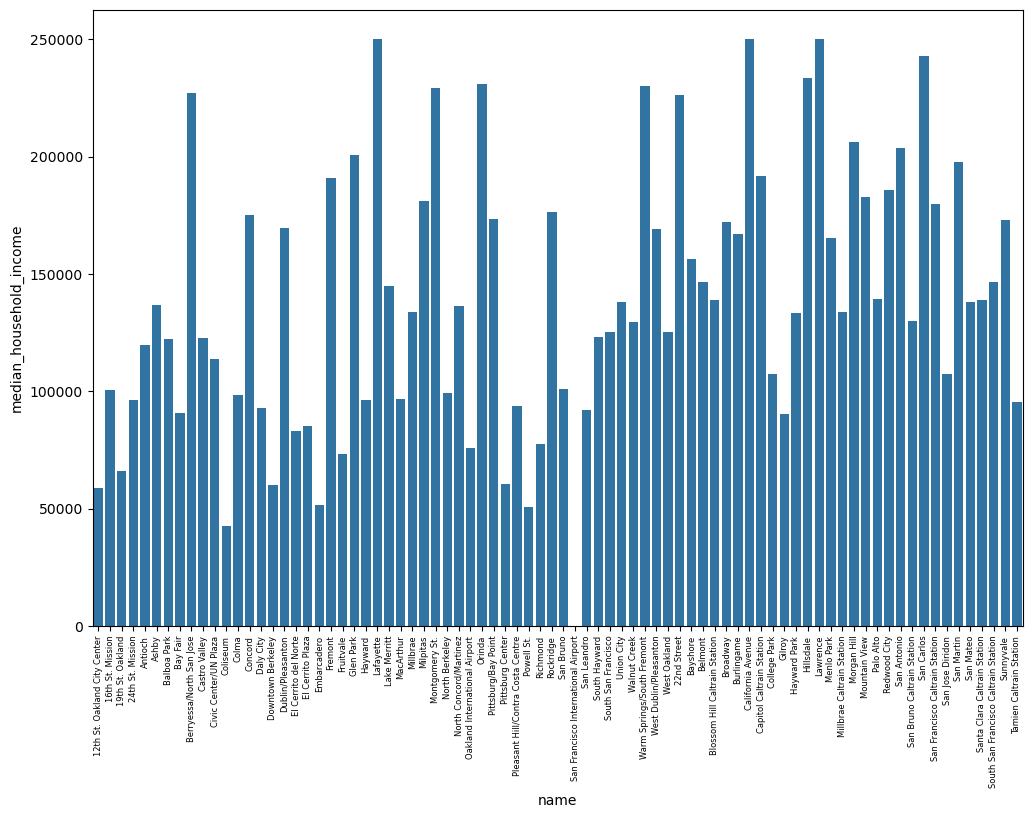

In [27]:
fig, ax = plt.subplots(figsize=(12,8))
sns.barplot(data = transit_census_df, x = "name", y = "median_household_income")
ax.set_xticklabels(transit_census_df['name'].values,rotation = 90, fontsize = 6)
plt.savefig("../visualizations/median_income_by_station.png", bbox_inches = "tight")
plt.show()

Not seeing where Downtown Berkeley BART station (4325) is causing issues. The values appear reasonable. Could the issues be from the older data before updating to 2024-2025?

## Visualizations

In [28]:
census_gdf = gpd.read_file("../data/census_tract_data_2024.csv")

tracts = gpd.read_file("../data/tl_2024_06_tract/tl_2024_06_tract.shp")
tracts = tracts.to_crs(epsg=3857)

bay_fips = ['001','013','041','055','075','081','085','095','097']

bay_tracts = tracts[
    (tracts['STATEFP'] == '06') &
    (tracts['COUNTYFP'].isin(bay_fips))
]

census = bay_tracts[['GEOID', 'geometry']].merge(census_gdf, on="GEOID")
census

,GEOID,geometry,NAME,total_pop,median_age,total_pop_race,white_alone,black_alone,aian_alone,asian_alone,nhpi_alone,other_race_alone,two_or_more_races,median_household_income,per_capita_income,total_pop_poverty_calc,pop_below_poverty,total_housing_units,total_occupied_units,owner_occupied,renter_occupied,total_households,owner_occ_no_vehicle,renter_occ_no_vehicle,median_gross_rent,median_home_value,total_workers_16plus,drove_alone,public_transit_commuters,bicycle_commuters,walked_commuters,worked_from_home,aggregate_travel_time_mins,labor_force,employed,unemployed,pop_25plus,bachelors_degree,masters_degree,professional_degree,doctorate_degree,foreign_born,total_pop_nativity,state,county,tract,county_name,households_no_vehicle,pct_no_vehicle,pop_nonwhite,pct_nonwhite,pct_white,pct_black,pct_asian,poverty_rate,pct_renter,pct_owner,pct_transit_commute,pct_drove_alone,pct_bike_commute,pct_walk_commute,pct_wfh,mean_travel_time_mins,unemployment_rate,pop_bachelors_plus,pct_bachelors_plus,pct_foreign_born
0,06001442700,"POLYGON ((-13582893.983 4514550.527, -13582891...",Census Tract 4427; Alameda County; California,3068,38.6,3068,945,82,0,1464,27,86,464,209625.0,84305.0,3057,90,1071,1071,831,240,1071,9,36,3222.0,1520500.0,1499,876,7,0,0,358,32700.0,1569,1537,32,2165,699,559,89,101,1387,3068,06,001,442700,Alameda,45,4.2,2123,69.2,30.8,2.67,47.72,2.94,22.41,77.59,0.47,58.44,0.0,0.0,23.88,21.81,2.04,1448,66.88,45.21
1,06001442800,"POLYGON ((-13581234.219 4513218.736, -13581226...",Census Tract 4428; Alameda County; California,3041,40.9,3041,846,32,12,1716,0,129,306,179844.0,66720.0,3031,101,953,953,750,203,953,8,5,3250.0,1114100.0,1457,815,32,0,8,380,,1649,1522,127,2275,775,342,40,49,1465,3041,06,001,442800,Alameda,13,1.36,2195,72.18,27.82,1.05,56.43,3.33,21.3,78.7,2.2,55.94,0.0,0.55,26.08,,7.7,1206,53.01,48.17
2,06001442900,"POLYGON ((-13579612.516 4512186.349, -13579602...",Census Tract 4429; Alameda County; California,7783,38.3,7783,924,404,40,4843,13,760,799,172308.0,67357.0,7778,229,2526,2526,1302,1224,2526,34,9,2946.0,1289900.0,4067,2068,342,28,35,1302,89190.0,4512,4188,324,5560,2073,1224,93,77,3754,7783,06,001,442900,Alameda,43,1.7,6859,88.13,11.87,5.19,62.23,2.94,48.46,51.54,8.41,50.85,0.69,0.86,32.01,21.93,7.18,3467,62.36,48.23
3,06095252204,"POLYGON ((-13605096.338 4616602.017, -13605092...",Census Tract 2522.04; Solano County; California,5874,41.3,5874,2231,660,0,1752,18,341,872,199821.0,70224.0,5862,173,1784,1784,1597,187,1784,11,0,3286.0,934500.0,2556,1738,36,4,63,501,68510.0,2823,2543,230,3637,1095,571,73,81,1043,5874,06,095,252204,Solano,11,0.62,3643,62.02,37.98,11.24,29.83,2.95,10.48,89.52,1.41,68.0,0.16,2.46,19.6,26.8,8.15,1820,50.04,17.76
4,06095252203,"POLYGON ((-13601002.303 4624135.025, -13600142...",Census Tract 2522.03; Solano County; California,4299,43.0,4299,1739,344,0,1249,63,54,850,165078.0,78127.0,4296,183,1709,1661,1291,370,1661,14,47,2865.0,813100.0,2258,1575,24,0,46,440,51425.0,2353,2288,34,3100,814,539,132,133,621,4299,06,095,252203,Solano,61,3.67,2560,59.55,40.45,8.0,29.05,4.26,22.28,77.72,1.06,69.75,0.0,2.04,19.49,22.77,1.44,1618,52.19,14.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1767,06013313102,"POLYGON ((-13566949.63 4579335.439, -13566947....",Census Tract 3131.02; Contra Costa County; Cal...,4732,37.8,4732,762,1539,69,724,0,770,868,86165.0,38276.0,4619,629,1669,1611,742,869,1611,12,77,2462.0,576400.0,2307,1943,181,0,33,57,89740.0,2717,2409,308,3255,344,165,0,17,1315,4732,06,013,313102,Contra Costa,89,5.52,3970,83.9,16.1,32.52,15.3,13.62,53.94,46.06,7.85,84.22,0.0,1.43,2.47,38.9,11.34,526,16.16,27.79
1768,06013314102,"POLYGON ((-13573499.441 4583395.627, -13573496...",Census Tract 3141.02; Contra Costa County; Cal...,6523,37.6,6523,1169,389,51,820,26,2737,1331,97429.0,336

In [29]:
mapping = pd.merge(transit, classification[['station_id', 'station_type', 'avg_weekday_exits']], how = "inner", left_on = 'name', 
         right_on='station_id')
mapping

,Unnamed: 0,station_id_x,name,latitude,longitude,address,city,county,zipcode,agency,mode,geometry,station_id_y,station_type,avg_weekday_exits
0,0,12TH,12th St. Oakland City Center,37.803768,-122.271450,1245 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.27145 37.803768),12th St. Oakland City Center,core,5164
1,1,16TH,16th St. Mission,37.765062,-122.419694,2000 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.419694 37.765062),16th St. Mission,core,5642
2,2,19TH,19th St. Oakland,37.808350,-122.268602,1900 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.268602 37.80835),19th St. Oakland,core,4606
3,3,24TH,24th St. Mission,37.752470,-122.418143,2800 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.418143 37.75247),24th St. Mission,core,5491
4,4,ANTC,Antioch,37.995388,-121.780420,1600 Slatten Ranch Road,Antioch,Contra Costa,94509.0,BART,Heavy Rail,POINT (-121.78042 37.995388),Antioch,peripheral,523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,75,san_mateo,San Mateo,37.568240,-122.323900,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.3239 37.56824),San Mateo,peripheral,1270
76,76,santa_clara,Santa Clara Caltrain Station,37.353384,-121.936465,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-121.936465 37.353384),Santa Clara Caltrain Station,peripheral,839
77,77,south_sf,South San Francisco Caltrain Station,37.655941,-122.404979,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.404979006 37.655941416),South San Francisco Caltrain Station,peripheral,692
78,79,sunnyvale,Sunnyvale,37.378934,-122.031500,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.0315 37.378934),Sunnyvale,peripheral,1770


/var/folders/f6/5lsnzlyn7b92g6y8m7735w000000gn/T/ipykernel_1224/3302926620.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/f6/5lsnzlyn7b92g6y8m7735w000000gn/T/ipykernel_1224/3302926620.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["BART", "Caltrain"])


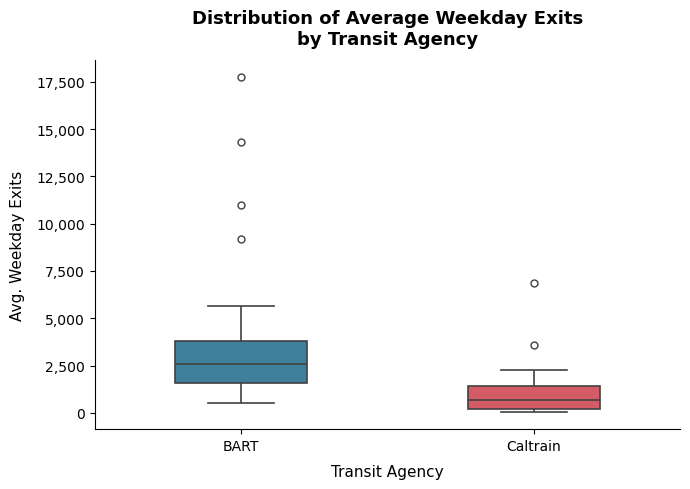

In [32]:
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 5))

palette = {"BART": "#2E86AB", "Caltrain": "#E84855"}

sns.boxplot(
    data=mapping,
    x="agency",
    y="avg_weekday_exits",
    palette=palette,
    width=0.45,
    linewidth=1.2,
    flierprops=dict(marker="o", markerfacecolor="none", markersize=5, linewidth=0.8),
    ax=ax
)

ax.set_xlabel("Transit Agency", fontsize=11, labelpad=8)
ax.set_ylabel("Avg. Weekday Exits", fontsize=11, labelpad=8)
ax.set_title("Distribution of Average Weekday Exits\nby Transit Agency", fontsize=13, fontweight="bold", pad=12)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(labelsize=10)

ax.set_xticklabels(["BART", "Caltrain"])

plt.tight_layout()
plt.savefig("../visualizations/exits_by_agency.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
census_transit_class = pd.merge(transit_census_df, classification[['station_id', 'station_type', 'avg_weekday_exits']], how = "inner", left_on = 'station', 
         right_on='station_id')
census_transit_class.head()

,station,geoid,state_x,county_x,tract_x,tract_name,Unnamed: 0,station_id_x,name,latitude,longitude,address,city,county_y,zipcode,agency,mode,geometry,station_id_y,station_type_x,NAME,total_pop,median_age,total_pop_race,white_alone,black_alone,aian_alone,asian_alone,nhpi_alone,other_race_alone,two_or_more_races,median_household_income,per_capita_income,total_pop_poverty_calc,pop_below_poverty,total_housing_units,total_occupied_units,owner_occupied,renter_occupied,total_households,owner_occ_no_vehicle,renter_occ_no_vehicle,median_gross_rent,median_home_value,total_workers_16plus,drove_alone,public_transit_commuters,bicycle_commuters,walked_commuters,worked_from_home,aggregate_travel_time_mins,labor_force,employed,unemployed,pop_25plus,bachelors_degree,masters_degree,professional_degree,doctorate_degree,foreign_born,total_pop_nativity,state_y,county,tract_y,GEOID,county_name,households_no_vehicle,pct_no_vehicle,pop_nonwhite,pct_nonwhite,pct_white,pct_black,pct_asian,poverty_rate,pct_renter,pct_owner,pct_transit_commute,pct_drove_alone,pct_bike_commute,pct_walk_commute,pct_wfh,mean_travel_time_mins,unemployment_rate,pop_bachelors_plus,pct_bachelors_plus,pct_foreign_born,station_id,station_type_y,avg_weekday_exits
0,12th St. Oakland City Center,06001403000,06,001,403000,Census Tract 4030,0,12TH,12th St. Oakland City Center,37.803768,-122.271450,1245 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.27145 37.803768),12th St. Oakland City Center,core,Census Tract 4030; Alameda County; California,3387,40.4,3387,444,320,2,2178,48,48,347,58794.0,60439.0,3387,799,2413,2034,353,1681,2034,182,1008,2128.0,573000.0,1659,331,440,0,137,707,NaN,1931,1760,171,3024,825,454,67,26,2062,3387,6,1,403000,06001403000,Alameda,1190,58.51,2943,86.89,13.11,9.45,64.30,23.59,82.65,17.35,26.52,19.95,0.00,8.26,42.62,NaN,8.86,1372,45.37,60.88,12th St. Oakland City Center,core,5164
1,16th St. Mission,06075020102,06,075,020102,Census Tract 201.02,1,16TH,16th St. Mission,37.765062,-122.419694,2000 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.419694 37.765062),16th St. Mission,core,Census Tract 201.02; San Francisco County; Cal...,3463,45.0,3463,981,272,57,623,0,1009,521,100761.0,55597.0,3463,948,1861,1306,221,1085,1306,60,639,1764.0,1098000.0,1668,432,315,87,248,467,NaN,2150,1684,466,2885,693,416,33,126,1126,3463,6,75,20102,06075020102,San Francisco,699,53.52,2482,71.67,28.33,7.85,17.99,27.38,83.08,16.92,18.88,25.90,5.22,14.87,28.00,NaN,21.67,1268,43.95,32.52,16th St. Mission,core,5642
2,19th St. Oakland,06001402900,06,001,402900,Census Tract 4029,2,19TH,19th St. Oakland,37.808350,-122.268602,1900 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.268602 37.80835),19th St. Oakland,core,Census Tract 4029; Alameda County; California,2431,37.2,2431,661,603,10,692,0,112,353,66050.0,89947.0,2417,515,2071,1715,12,1703,1715,0,1029,2096.0,NaN,1496,298,484,19,86,446,NaN,1648,1525,123,2182,829,377,41,85,710,2431,6,1,402900,06001402900,Alameda,1029,60.00,1770,72.81,27.19,24.80,28.47,21.31,99.30,0.70,32.35,19.92,1.27,5.75,29.81,NaN,7.46,1332,61.04,29.21,19th St. Oakland,core,4606
3,24th St. Mission,06075020900,06,075,020900,Census Tract 209,3,24TH,24th St. Mission,37.752470,-122.418143,2800 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.418143 37.75247),24th St. Mission,core,Census Tract 209; San Francisco County; Califo...,3746,38.4,3746,1222,38,33,612,0,1170,671,96250.0,67562.0,3733,387,1898,1607,223,1384,1607,50,480,2446.0,1296100.0,2157,438,715,114,101,730,43075.0,2478,2279,199,2979,1144,474,111,156,1180,3746,6,75,20900,06075020900,San Francisco,530,32.98,2524,67.38,32.62,1.01,16.34,10.37,86.12,13.88,33.15,20.31,5.29,4.68,33.84,19.97,8.03,1885,63.28,31.50,24th St. Mission,core,5491
4,Antioch,06013308002,06,013,308002,Census Tract 3080.02,4,ANTC,Antioch,37.995388,-121.780420,1600 Slatten Ranch Road,Antioch,Contra Costa,94509.0,BART,Heavy Rail,POINT (-121.78042 37.995388),Antioch,peripheral

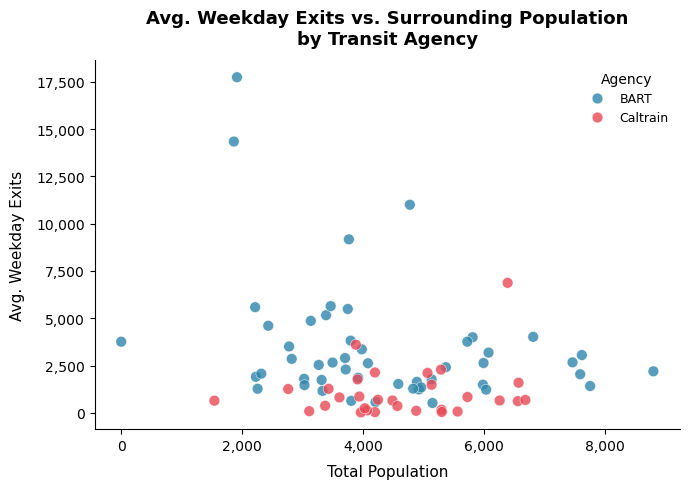

In [36]:
fig, ax = plt.subplots(figsize=(7, 5))

palette = {"BART": "#2E86AB", "Caltrain": "#E84855"}

sns.scatterplot(
    data=census_transit_class,
    x="total_pop",
    y="avg_weekday_exits",
    hue="agency",
    palette=palette,
    s=60,
    alpha=0.8,
    edgecolors="white",
    linewidth=0.4,
    ax=ax
)

ax.set_xlabel("Total Population", fontsize=11, labelpad=8)
ax.set_ylabel("Avg. Weekday Exits", fontsize=11, labelpad=8)
ax.set_title("Avg. Weekday Exits vs. Surrounding Population\nby Transit Agency", fontsize=13, fontweight="bold", pad=12)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(labelsize=10)

ax.legend(title="Agency", title_fontsize=10, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("../visualizations/exits_by_agency_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

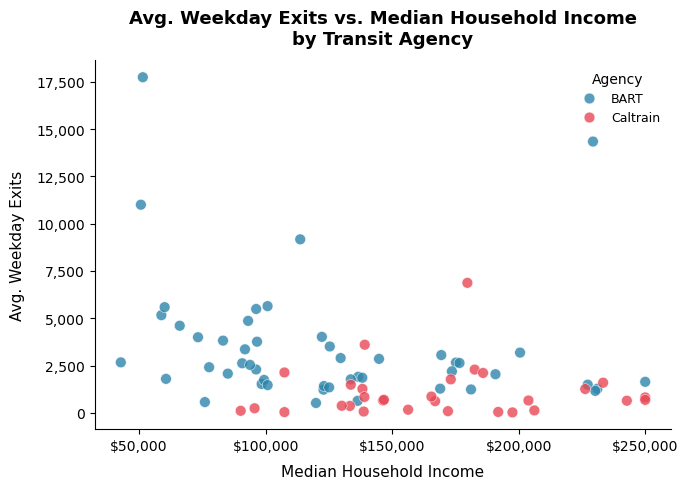

In [38]:
fig, ax = plt.subplots(figsize=(7, 5))

palette = {"BART": "#2E86AB", "Caltrain": "#E84855"}

sns.scatterplot(
    data=census_transit_class,
    x="median_household_income",
    y="avg_weekday_exits",
    hue="agency",
    palette=palette,
    s=60,
    alpha=0.8,
    edgecolors="white",
    linewidth=0.4,
    ax=ax
)

ax.set_xlabel("Median Household Income", fontsize=11, labelpad=8)
ax.set_ylabel("Avg. Weekday Exits", fontsize=11, labelpad=8)
ax.set_title("Avg. Weekday Exits vs. Median Household Income\nby Transit Agency", fontsize=13, fontweight="bold", pad=12)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x):,}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)
ax.tick_params(labelsize=10)

ax.legend(title="Agency", title_fontsize=10, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("../visualizations/income_vs_exits_by_agency.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
full = census_transit_class.merge(census[['GEOID', 'geometry']], how = 'left', left_on='geoid', right_on='GEOID')
full

,station,geoid,state_x,county_x,tract_x,tract_name,Unnamed: 0,station_id_x,name,latitude,longitude,address,city,county_y,zipcode,agency,mode,geometry_x,station_id_y,station_type_x,NAME,total_pop,median_age,total_pop_race,white_alone,black_alone,aian_alone,asian_alone,nhpi_alone,other_race_alone,two_or_more_races,median_household_income,per_capita_income,total_pop_poverty_calc,pop_below_poverty,total_housing_units,total_occupied_units,owner_occupied,renter_occupied,total_households,owner_occ_no_vehicle,renter_occ_no_vehicle,median_gross_rent,median_home_value,total_workers_16plus,drove_alone,public_transit_commuters,bicycle_commuters,walked_commuters,worked_from_home,aggregate_travel_time_mins,labor_force,employed,unemployed,pop_25plus,bachelors_degree,masters_degree,professional_degree,doctorate_degree,foreign_born,total_pop_nativity,state_y,county,tract_y,GEOID_x,county_name,households_no_vehicle,pct_no_vehicle,pop_nonwhite,pct_nonwhite,pct_white,pct_black,pct_asian,poverty_rate,pct_renter,pct_owner,pct_transit_commute,pct_drove_alone,pct_bike_commute,pct_walk_commute,pct_wfh,mean_travel_time_mins,unemployment_rate,pop_bachelors_plus,pct_bachelors_plus,pct_foreign_born,station_id,station_type_y,avg_weekday_exits,GEOID_y,geometry_y
0,12th St. Oakland City Center,06001403000,06,001,403000,Census Tract 4030,0,12TH,12th St. Oakland City Center,37.803768,-122.271450,1245 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.27145 37.803768),12th St. Oakland City Center,core,Census Tract 4030; Alameda County; California,3387,40.4,3387,444,320,2,2178,48,48,347,58794.0,60439.0,3387,799,2413,2034,353,1681,2034,182,1008,2128.0,573000.0,1659,331,440,0,137,707,NaN,1931,1760,171,3024,825,454,67,26,2062,3387,6,1,403000,06001403000,Alameda,1190,58.51,2943,86.89,13.11,9.45,64.30,23.59,82.65,17.35,26.52,19.95,0.00,8.26,42.62,NaN,8.86,1372,45.37,60.88,12th St. Oakland City Center,core,5164,06001403000,"POLYGON ((-13611590.818 4550988.94, -13611580...."
1,16th St. Mission,06075020102,06,075,020102,Census Tract 201.02,1,16TH,16th St. Mission,37.765062,-122.419694,2000 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.419694 37.765062),16th St. Mission,core,Census Tract 201.02; San Francisco County; Cal...,3463,45.0,3463,981,272,57,623,0,1009,521,100761.0,55597.0,3463,948,1861,1306,221,1085,1306,60,639,1764.0,1098000.0,1668,432,315,87,248,467,NaN,2150,1684,466,2885,693,416,33,126,1126,3463,6,75,20102,06075020102,San Francisco,699,53.52,2482,71.67,28.33,7.85,17.99,27.38,83.08,16.92,18.88,25.90,5.22,14.87,28.00,NaN,21.67,1268,43.95,32.52,16th St. Mission,core,5642,06075020102,"POLYGON ((-13627959.726 4546498.189, -13627902..."
2,19th St. Oakland,06001402900,06,001,402900,Census Tract 4029,2,19TH,19th St. Oakland,37.808350,-122.268602,1900 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.268602 37.80835),19th St. Oakland,core,Census Tract 4029; Alameda County; California,2431,37.2,2431,661,603,10,692,0,112,353,66050.0,89947.0,2417,515,2071,1715,12,1703,1715,0,1029,2096.0,NaN,1496,298,484,19,86,446,NaN,1648,1525,123,2182,829,377,41,85,710,2431,6,1,402900,06001402900,Alameda,1029,60.00,1770,72.81,27.19,24.80,28.47,21.31,99.30,0.70,32.35,19.92,1.27,5.75,29.81,NaN,7.46,1332,61.04,29.21,19th St. Oakland,core,4606,06001402900,"POLYGON ((-13611176.038 4551825.521, -13611160..."
3,24th St. Mission,06075020900,06,075,020900,Census Tract 209,3,24TH,24th St. Mission,37.752470,-122.418143,2800 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.418143 37.75247),24th St. Mission,core,Census Tract 209; San Francisco County; Califo...,3746,38.4,3746,1222,38,33,612,0,1170,671,96250.0,67562.0,3733,387,1898,1607,223,1384,1607,50,480,2446.0,1296100.0,2157,438,715,114,101,730,43075.0,2478,2279,199,2979,1144,474,111,156,1180,3746,6,75,20900,06075020900,San Francisco,530,32.98,2524,67.38,32.62,1.01,16.34,10.37,86.12,13.88,33.15,20.31,5.29,4.68,33.84,19.97,8.03,1885,63.28,31.50,24th St. Mission,core,

In [40]:
full_gdf = gpd.GeoDataFrame(
    full, 
    geometry= 'geometry_y',
    crs="EPSG:3857" # WGS84
)

### Missing Data

In [41]:
variables = ["median_household_income", 
             "pct_no_vehicle", 
             "pct_nonwhite", 
             "pct_transit_commute", 
             "avg_weekday_exits"]
for var in variables:
    print(f"{var}: {full_gdf[full_gdf[var].isnull()]['station']}")

median_household_income: 41    San Francisco International Airport
Name: station, dtype: str
pct_no_vehicle: 41    San Francisco International Airport
Name: station, dtype: str
pct_nonwhite: 41    San Francisco International Airport
Name: station, dtype: str
pct_transit_commute: 41    San Francisco International Airport
Name: station, dtype: str
avg_weekday_exits: Series([], Name: station, dtype: str)


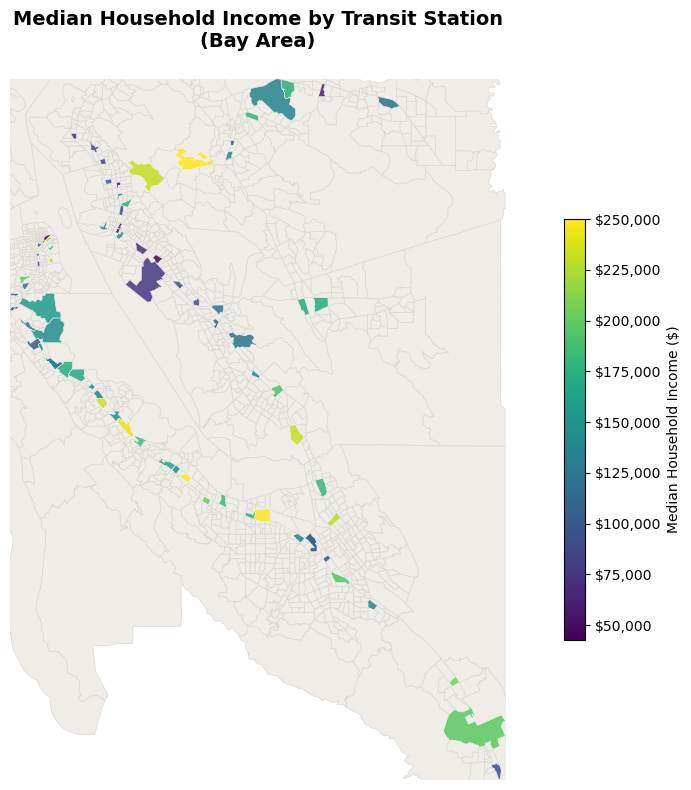

In [44]:
fig, ax = plt.subplots(figsize=(12, 8))

census.plot(ax=ax, color="#F0EDE8", edgecolor="#DDD9D3", linewidth=0.5)

full_gdf.plot(
    ax=ax,
    column="median_household_income",
    cmap="viridis",
    legend=True,
    markersize=40,
    alpha=0.85,
    edgecolors="white",
    linewidth=0.4,
    legend_kwds={
        "label": "Median Household Income ($)",
        "orientation": "vertical",
        "shrink": 0.6,
        "format": plt.FuncFormatter(lambda x, _: f"${int(x):,}")
    }
)

# get bounding box from station data with some padding
minx, miny, maxx, maxy = full_gdf.total_bounds
pad = 0.1  # degrees

ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

ax.set_title("Median Household Income by Transit Station\n(Bay Area)", fontsize=14, fontweight="bold", pad=12)
ax.set_axis_off()

plt.tight_layout()
# plt.savefig("../visualizations/median_income_map.png", dpi=300, bbox_inches="tight")
plt.show()

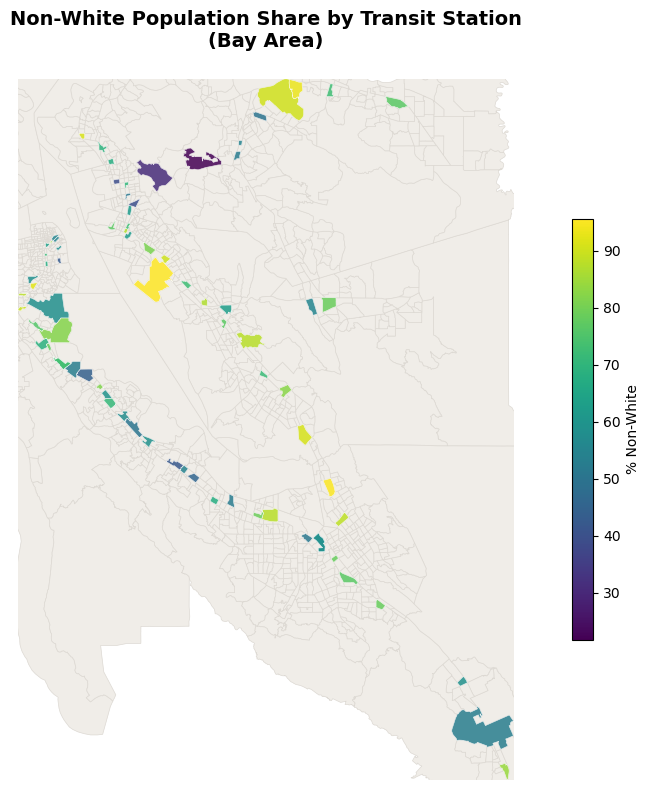

In [47]:
fig, ax = plt.subplots(figsize=(12, 8))

census.plot(ax=ax, color="#F0EDE8", edgecolor="#DDD9D3", linewidth=0.5)

full_gdf.plot(
    ax=ax,
    column="pct_nonwhite",
    cmap="viridis",
    legend=True,
    markersize=40,
    alpha=0.85,
    edgecolors="white",
    linewidth=0.4,
    legend_kwds={
    "label": "% Non-White",
    "orientation": "vertical",
    "shrink": 0.6,
}
)

ax.set_title("Non-White Population Share by Transit Station\n(Bay Area)", fontsize=14, fontweight="bold", pad=12)
ax.set_axis_off()

minx, miny, maxx, maxy = full_gdf.total_bounds
pad = 0.1
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

plt.tight_layout()
plt.savefig("../visualizations/pct_nonwhite_map.png", dpi=300, bbox_inches="tight")
plt.show()

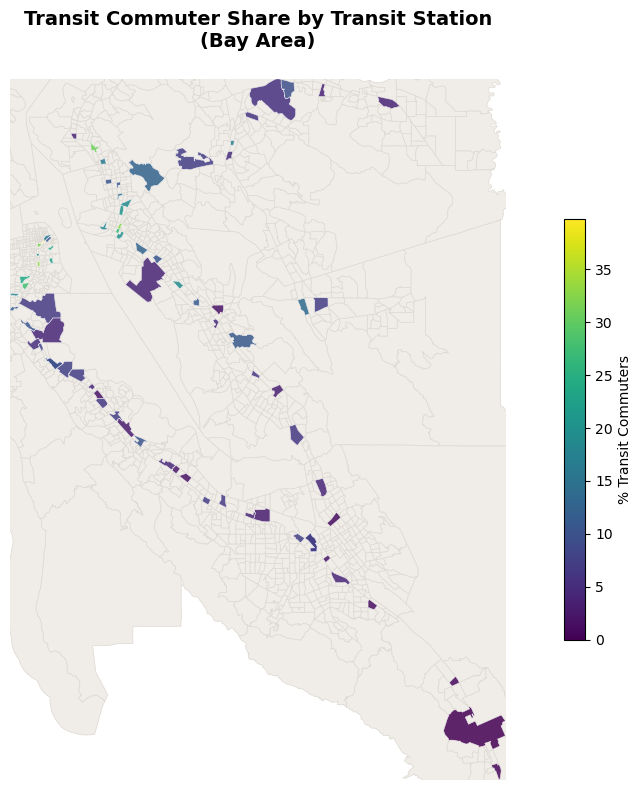

In [49]:
fig, ax = plt.subplots(figsize=(12, 8))

census.plot(ax=ax, color="#F0EDE8", edgecolor="#DDD9D3", linewidth=0.5)

full_gdf.plot(
    ax=ax,
    column="pct_transit_commute",
    cmap="viridis",
    legend=True,
    markersize=40,
    alpha=0.85,
    edgecolors="white",
    linewidth=0.4,
    legend_kwds={
        "label": "% Transit Commuters",
        "orientation": "vertical",
        "shrink": 0.6,
    }
)

ax.set_title("Transit Commuter Share by Transit Station\n(Bay Area)", fontsize=14, fontweight="bold", pad=12)
ax.set_axis_off()

minx, miny, maxx, maxy = full_gdf.total_bounds
pad = 0.1
ax.set_xlim(minx - pad, maxx + pad)
ax.set_ylim(miny - pad, maxy + pad)

plt.tight_layout()
plt.savefig("../visualizations/pct_transit_commute_map.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
full_gdf.explore(column="median_household_income", cmap="viridis", legend = True)

In [51]:
full_gdf.columns

Index(['station', 'geoid', 'state_x', 'county_x', 'tract_x', 'tract_name',
       'Unnamed: 0', 'station_id_x', 'name', 'latitude', 'longitude',
       'address', 'city', 'county_y', 'zipcode', 'agency', 'mode',
       'geometry_x', 'station_id_y', 'station_type_x', 'NAME', 'total_pop',
       'median_age', 'total_pop_race', 'white_alone', 'black_alone',
       'aian_alone', 'asian_alone', 'nhpi_alone', 'other_race_alone',
       'two_or_more_races', 'median_household_income', 'per_capita_income',
       'total_pop_poverty_calc', 'pop_below_poverty', 'total_housing_units',
       'total_occupied_units', 'owner_occupied', 'renter_occupied',
       'total_households', 'owner_occ_no_vehicle', 'renter_occ_no_vehicle',
       'median_gross_rent', 'median_home_value', 'total_workers_16plus',
       'drove_alone', 'public_transit_commuters', 'bicycle_commuters',
       'walked_commuters', 'worked_from_home', 'aggregate_travel_time_mins',
       'labor_force', 'employed', 'unemployed', 'pop_25

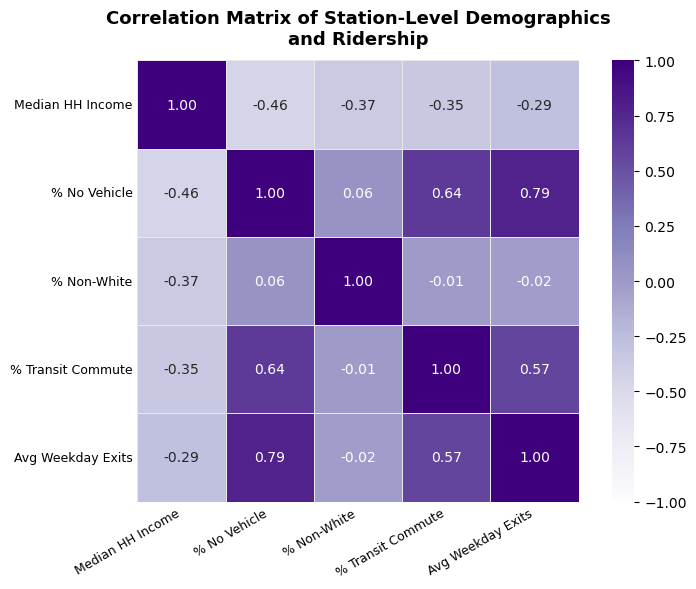

In [57]:
fig, ax = plt.subplots(figsize=(8, 6))

corr = full_gdf[variables].corr()

labels = [
    "Median HH Income",
    "% No Vehicle",
    "% Non-White",
    "% Transit Commute",
    "Avg Weekday Exits"
]

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Purples",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor="#E8E8E8",
    annot_kws={"size": 10},
    xticklabels=labels,
    yticklabels=labels,
    ax=ax
)

ax.set_title("Correlation Matrix of Station-Level Demographics\nand Ridership", fontsize=13, fontweight="bold", pad=12)
ax.tick_params(labelsize=9, length=0)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("../visualizations/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
summary = full_gdf.groupby('station_type_y')[variables].mean()
summary

,median_household_income,pct_no_vehicle,pct_nonwhite,pct_transit_commute,avg_weekday_exits
station_type_y,,,,,
core,118551.897436,22.878718,69.278462,15.542308,4258.35
peripheral,163149.550000,6.465000,66.989750,6.031500,851.90


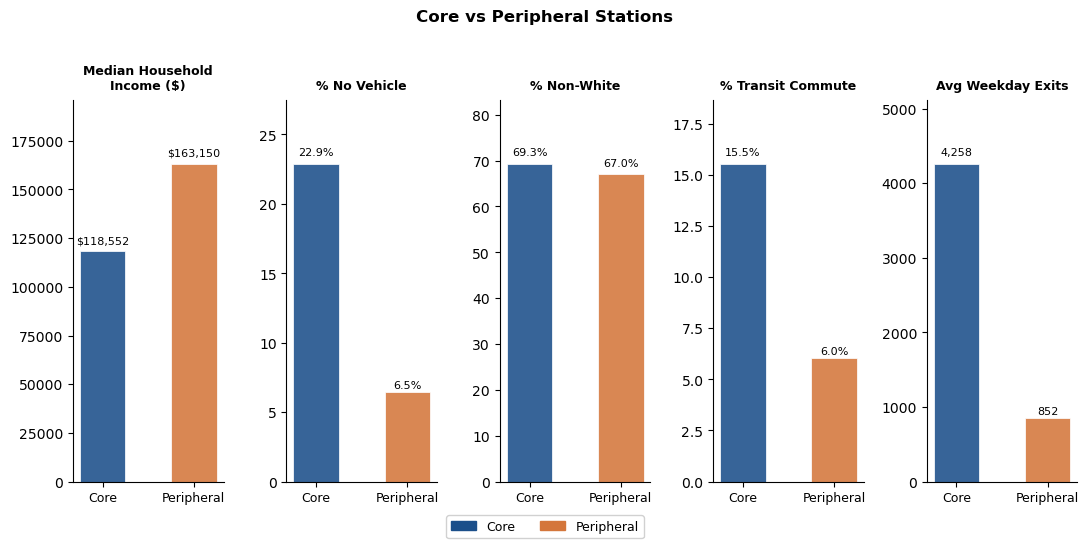

In [60]:
COLORS = {"core": "#1B4F8A", "peripheral": "#D4763B"}
 
labels = {
    "median_household_income": "Median Household\nIncome ($)",
    "pct_no_vehicle":          "% No Vehicle",
    "pct_nonwhite":            "% Non-White",
    "pct_transit_commute":     "% Transit Commute",
    "avg_weekday_exits":       "Avg Weekday Exits",
}

variables = list(labels.keys())
x         = np.arange(len(variables))
width     = 0.35
 
fig, axes = plt.subplots(1, len(variables), figsize=(11, 5))
 
for ax, var in zip(axes, variables):
    for i, (group, color) in enumerate(COLORS.items()):
        val  = summary.loc[group, var]
        bar  = ax.bar(i, val, color=color, alpha=0.88,
                      edgecolor="white", linewidth=0.6, width=0.5)
 
        # Format value label based on variable type
        if "income" in var:
            fmt = f"${val:,.0f}"
        elif "exits" in var:
            fmt = f"{val:,.0f}"
        else:
            fmt = f"{val:.1f}%"
 
        ax.text(i, val + val * 0.02, fmt,
                ha="center", va="bottom", fontsize=8)
 
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Core", "Peripheral"], fontsize=9)
    ax.set_title(labels[var], fontsize=9, fontweight="bold", pad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0, max(summary[var]) * 1.2)   # consistent headroom for labels
 
# Shared legend
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS["core"],       label="Core"),
    plt.Rectangle((0, 0), 1, 1, color=COLORS["peripheral"],  label="Peripheral"),
]
fig.legend(handles=legend_patches, loc="lower center",
           ncol=2, fontsize=9, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.05))
 
fig.suptitle("Core vs Peripheral Stations",
             fontsize=12, fontweight="bold", y=1.02)
 
plt.tight_layout()
plt.savefig("../visualizations/core_vs_per_summary.png", dpi=300, bbox_inches="tight")
